In [24]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama 
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator


In [25]:
llm = ChatOllama(model='llama3.2:3b')


In [26]:
# for structured output

class EvaluationSchema(BaseModel):
    feedback :  str = Field(description ='Detailed feedback for the essay')
    score    :  int = Field (description= 'Score out of 10', ge=0, le=10)

In [27]:
structured_llm = llm.with_structured_output(EvaluationSchema)

In [28]:
essay = """
Artificial Intelligence (AI) has rapidly transformed the technology landscape, bringing efficiency, automation, and innovation across industries. While AI has created new opportunities, it has also raised concerns about the future of IT jobs. Many professionals fear that increasing automation may reduce the demand for certain roles, fundamentally reshaping the workforce.
One of the primary reasons AI is seen as a threat is its ability to automate repetitive and rule-based tasks. In IT, roles such as manual testing, basic coding, technical support, and data entry are particularly vulnerable. AI-powered tools can now generate code, detect bugs, perform testing, and even provide customer support through chatbots. This reduces the need for human intervention in routine tasks, potentially leading to job displacement.
Another major factor is the rise of low-code and no-code platforms. These tools allow non-technical users to build applications with minimal coding knowledge. As a result, the demand for entry-level developers and testers may decline. Similarly, AI-driven DevOps and automation pipelines are reducing the need for large operations teams, as systems can now monitor, deploy, and fix issues with minimal human involvement.
However, it is important to understand that AI is not entirely replacing jobs—it is transforming them. While some roles may diminish, new roles are emerging in areas such as AI development, machine learning engineering, data science, and AI ethics. IT professionals who upskill and adapt to these changes can remain relevant and even benefit from higher-paying opportunities.
Moreover, AI still lacks human qualities such as creativity, critical thinking, and emotional intelligence. Complex problem-solving, system design, and strategic decision-making continue to require human expertise. Roles that involve innovation, leadership, and collaboration are less likely to be replaced by AI.
To mitigate the threat, continuous learning is essential. IT professionals must upgrade their skills in areas like automation tools, programming, cloud computing, and AI technologies. Organizations and governments also play a crucial role by providing training programs and encouraging reskilling initiatives.
In conclusion, while AI poses a significant challenge to certain IT jobs, it also opens the door to new possibilities. The key lies in adaptability. Those who embrace change, learn new skills, and evolve with technology will not only survive but thrive in the AI-driven future.
"""

In [29]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n{essay}'

op= structured_llm.invoke(prompt)

In [30]:
op.feedback

'The essay provides a comprehensive overview of the impact of Artificial Intelligence (AI) on the IT industry, highlighting both the challenges and opportunities it presents. The writer uses relevant examples and data to support their arguments, making the content engaging and informative. However, there are areas for improvement in terms of language quality, clarity, and concision.'

In [31]:
op.score

8

In [32]:
class EssayState(TypedDict):

    essay: str
    
    feedback_thought: str
    feedback_analysis: str
    feedback_language: str

    # reducer function - add
    individual_scores: Annotated[list[int], operator.add]

    overall_feedback: str
    overall_score: float


In [33]:
def clarity_of_thought(state: EssayState):
    essay = state['essay']
    prompt = f'Evaluate the following essay based upon clarity of thought and provide a feedback and assign a score out of 10 \n{essay}'

    clarity_of_thought_output = structured_llm.invoke(prompt)

    feedback_thought = clarity_of_thought_output.feedback
    score_thought = clarity_of_thought_output.score

    #state['feedback_thought'] = feedback_thought
    #state['score_thought'] = score_thought

    return {'feedback_thought':feedback_thought, 'individual_scores':[score_thought]}

In [34]:
def depth_of_analysis(state: EssayState):
    essay = state['essay']
    prompt = f'Evaluate the following essay based upon depth of analysis and provide a feedback and assign a score out of 10 \n{essay}'

    depth_of_analysis_output = structured_llm.invoke(prompt)

    feedback_analysis = depth_of_analysis_output.feedback
    score_analysis = depth_of_analysis_output.score

    #state['feedback_analysis'] = feedback_analysis
    #state['score_analysis'] = score_analysis

    return {'feedback_analysis':feedback_analysis, 'individual_scores':[score_analysis]}


In [35]:
def language(state: EssayState):
    essay = state['essay']
    prompt = f'Evaluate the following essay based upon language and provide a feedback and assign a score out of 10 \n{essay}'

    language_output = structured_llm.invoke(prompt)

    feedback_language = language_output.feedback
    score_language = language_output.score

    #state['feedback_language'] = feedback_language
    #state['score_language'] = score_language

    return {'feedback_language':feedback_language, 'individual_scores':[score_language]}

In [36]:
def overall(state: EssayState):

    feedback_thought = state['feedback_thought']
    feedback_analysis = state['feedback_analysis']
    feedback_language = state['feedback_language']

    prompt = f'Based upon the given feedbacks , generate a summarised feedback .\n Feedback on clarity of thought - {feedback_thought}, Feedback on depth of anaylsis - {feedback_analysis},Feedback on language - {feedback_language}'

    summarised_feedback = llm.invoke(prompt).content 

    average_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback':summarised_feedback , 'overall_score': average_score}

               

In [37]:
graph = StateGraph(EssayState)

# add nodes

graph.add_node('clarity_of_thought', clarity_of_thought)
graph.add_node('depth_of_analysis', depth_of_analysis)
graph.add_node('language', language)

graph.add_node('overall',overall)


# add edges

graph.add_edge(START, 'clarity_of_thought')
graph.add_edge(START, 'depth_of_analysis')
graph.add_edge(START, 'language')

graph.add_edge('clarity_of_thought','overall')
graph.add_edge('depth_of_analysis','overall')
graph.add_edge('language','overall')

graph.add_edge('overall',END)


# compile graph

workflow = graph.compile()

In [40]:
initial_state = {'essay' : essay}

final_state = workflow.invoke(initial_state)

summarised_feedback = final_state['overall_feedback']
overall_score = final_state['overall_score']

print(f'Summarised feedback - {summarised_feedback} and overall score - {overall_score}')

Summarised feedback - Based on the provided feedbacks, here's a summarized feedback:

**Strengths:**

* The essay provides a clear and concise overview of the impact of Artificial Intelligence (AI) on the IT industry.
* The analysis is well-structured and easy to follow.
* The essay highlights both the challenges and opportunities presented by AI.

**Areas for improvement:**

* Increase clarity and depth: While the essay covers key points, it would benefit from more specific examples and case studies to support arguments.
* Enhance depth of analysis: Further exploration of the topic could provide a more comprehensive understanding of the impact of AI on the IT industry.
* Improve language: Vary sentence structures, use active voice, and eliminate wordy or unnecessary phrases to make the essay more engaging and polished.

**Recommendations:**

* Provide specific examples and case studies to support arguments.
* Consider adding more nuanced analysis of the challenges and opportunities pr

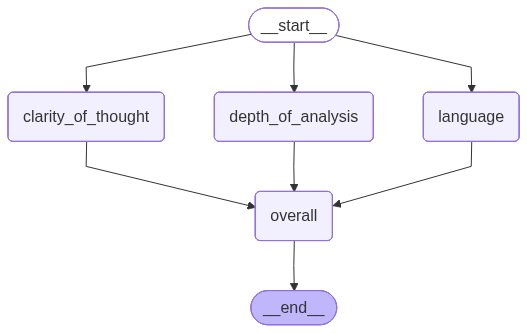

In [41]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [42]:
workflow.invoke(initial_state)

{'essay': '\nArtificial Intelligence (AI) has rapidly transformed the technology landscape, bringing efficiency, automation, and innovation across industries. While AI has created new opportunities, it has also raised concerns about the future of IT jobs. Many professionals fear that increasing automation may reduce the demand for certain roles, fundamentally reshaping the workforce.\nOne of the primary reasons AI is seen as a threat is its ability to automate repetitive and rule-based tasks. In IT, roles such as manual testing, basic coding, technical support, and data entry are particularly vulnerable. AI-powered tools can now generate code, detect bugs, perform testing, and even provide customer support through chatbots. This reduces the need for human intervention in routine tasks, potentially leading to job displacement.\nAnother major factor is the rise of low-code and no-code platforms. These tools allow non-technical users to build applications with minimal coding knowledge. As